# Custom State: 대화 기록과 업무 데이터를 함께 저장하기

## 왜 Custom State가 필요한가

`MessagesState`는 대화 이력을 담는 `messages` key와 message 누적 규칙을 미리 제공한다. 그러나 실제 앱은 검색어, API 결과, 승인 여부처럼 대화 이력 밖의 값도 다음 단계에 전달해야 한다.

이 예제는 `TypedDict`로 `messages` 규칙을 직접 선언하고 `search_query`, `search_results`를 추가한다. 이렇게 업무에 필요한 key를 직접 설계한 상태를 **Custom State**라고 한다.

> 핵심은 자연어 답변과 구조화된 업무 데이터를 분리하는 것이다. LLM은 `messages`에서 Tool 결과를 읽고, 화면·로그·후속 코드는 `search_query`와 `search_results`를 바로 사용한다.


## 패키지 설치

현재 Jupyter kernel에 예제 실행에 필요한 패키지를 설치한다.

- `langgraph`: State·Node·Edge로 실행 흐름을 구성한다.
- `langchain-openai`: OpenAI Chat Model을 연결한다.
- `requests`: 카카오 장소 검색 API에 HTTP 요청을 보낸다.
- `python-dotenv`: `.env`의 환경 변수를 불러온다.

설치 성공은 코드 의존성만 준비되었다는 뜻이다. OpenAI·카카오 API 호출에는 별도의 key와 네트워크가 필요하다.


In [1]:
%pip install -U langgraph langchain-openai requests python-dotenv


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## OpenAI와 카카오 인증 준비

이 예제의 외부 호출은 두 종류이다. LLM 호출에는 `OPENAI_API_KEY`, 장소 검색에는 `KAKAOMAP_API_KEY`가 필요하다. `.env`에는 다음처럼 **변수 이름과 자신의 값**을 등록한다.

```ini
OPENAI_API_KEY=발급받은_OpenAI_key
KAKAOMAP_API_KEY=카카오_REST_API_key
OPENAI_CHAT_MODEL=gpt-5.6-luna
```

`OPENAI_CHAT_MODEL`은 선택값이며 없으면 코드의 기본 모델을 사용한다. `LANGSMITH_API_KEY`도 선택값이므로 없어도 그래프는 실행된다. 실제 key는 노트북에 직접 적거나 출력하지 않는다.


In [2]:
import os
from dotenv import find_dotenv, load_dotenv

dotenv_path = find_dotenv(usecwd=True)
if dotenv_path:
    load_dotenv(dotenv_path, override=False)

if os.getenv("LANGSMITH_API_KEY"):
    os.environ.setdefault("LANGSMITH_TRACING", "true")
    os.environ.setdefault("LANGSMITH_PROJECT", "langgraph-custom-state")

OPENAI_CHAT_MODEL = os.getenv("OPENAI_CHAT_MODEL", "gpt-5.6-luna")


## 1단계: 카카오 장소 검색 Tool 만들기

`kakao_search_place`는 검색어를 받아 카카오 API의 큰 응답에서 수업에 필요한 세 값만 남긴다.

`query 문자열` → `HTTP GET` → `documents 목록` → `name·address·url 목록` → `JSON 문자열`

Tool이 반환한 JSON 문자열은 그래프 실행 시 `ToolMessage.content`에 저장된다. 이후 `capture_tool_output`이 이 문자열을 다시 `list[KakaoPlace]`로 변환한다. HTTP 상태가 4xx·5xx이면 `raise_for_status()`가 예외를 발생시키므로 인증·요청 오류를 빈 결과와 구분할 수 있다.


In [3]:
import json
import os
from pprint import pprint

import requests
from langchain_core.tools import tool

KAKAOMAP_API_KEY = os.getenv("KAKAOMAP_API_KEY")

@tool
def kakao_search_place(query: str) -> str:
    """카카오 장소 검색 API에서 이름·주소·URL을 최대 다섯 건 조회한다."""
    # 입력 query: 카카오 API가 검색할 문자열이다.
    # url: 키워드 장소 검색 endpoint이다.
    url = "https://dapi.kakao.com/v2/local/search/keyword.json"
    # Authorization header: KakaoAK 방식으로 REST API key를 전달한다.
    headers = {"Authorization": f"KakaoAK {KAKAOMAP_API_KEY}"}
    # size=5: API가 반환할 장소 수의 상한이다.
    params = {"query": query, "size": 5}

    # requests.get(url, headers, params, timeout): 검색 조건을 HTTP GET 요청으로 보낸다.
    response = requests.get(
        url,              # url: 카카오 키워드 장소 검색 endpoint이다.
        headers=headers,  # headers: REST API key를 담은 인증 header이다.
        params=params,    # params: query와 최대 결과 수 size를 담은 query parameter이다.
        timeout=10,       # timeout: 서버 응답을 최대 10초까지 기다린다.
    )
    # raise_for_status(): 4xx·5xx를 즉시 예외로 바꿔 인증 실패와 빈 검색 결과를 구분한다.
    response.raise_for_status()
    # response.json(): HTTP 본문을 dict로 변환하고 documents가 없으면 빈 list를 사용한다.
    documents = response.json().get("documents", [])
    # places: 각 원본 문서에서 화면·후속 코드가 사용할 세 field만 선택한 list[dict]이다.
    places = [
        {
            "name": place["place_name"],
            "address": place["address_name"],
            "url": place["place_url"],
        }
        for place in documents
    ]
    # json.dumps(obj, ensure_ascii): list[dict]를 ToolMessage.content에 들어갈 JSON str로 바꾼다.
    return json.dumps(
        places,              # obj: 이름·주소·URL만 남긴 장소 목록이다.
        ensure_ascii=False,  # ensure_ascii: False이면 한글을 그대로 유지한다.
    )

# Tool.invoke(input): query key를 Tool 입력 schema에 맞춰 전달하고 JSON str를 받는다.
# json.loads(str): 미리 보기에서는 JSON str를 Python list[dict]로 되돌린다.
preview_places = json.loads(
    kakao_search_place.invoke(
        {"query": "남부터미널 맛집"},  # query: Tool을 단독 점검할 검색 문자열이다.
    )
)
# [:2]: 최대 다섯 건 중 앞의 두 건만 읽기 쉽게 출력한다.
pprint(preview_places[:2])


[{'address': '서울 서초구 서초동 1451-9',
  'name': '봉산옥 서초동본점',
  'url': 'http://place.map.kakao.com/7908112'},
 {'address': '서울 서초구 서초동 1445-13',
  'name': '루엘드파리 서초본점',
  'url': 'http://place.map.kakao.com/26455895'}]


## 2단계: LLM으로 검색어 추출 Tool 만들기

`extract_keywords`는 긴 사용자 문장을 카카오 API가 검색하기 쉬운 짧은 검색어로 바꾼다. 입력은 `user_request: str`, 출력은 설명을 제거한 검색어 `str`이다.

이 셀은 Responses API를 사용한다. 이때 `AIMessage.content`는 문자열 또는 content block 목록일 수 있으므로, 텍스트만 일관되게 읽는 `AIMessage.text`를 사용한다.


In [5]:
from langchain_openai import ChatOpenAI

keyword_llm = ChatOpenAI(
    model=OPENAI_CHAT_MODEL,   # model: 앞에서 정한 OpenAI Chat Model ID이다.
    use_responses_api=True,    # use_responses_api: Responses API 형식으로 호출한다.
)

@tool
def extract_keywords(user_request: str) -> str:
    """사용자 문장에서 카카오 장소 검색에 사용할 짧은 검색어만 추출."""

    prompt = f"""
다음 요청을 카카오 장소 검색용 키워드 한 문장으로 바꾼다.
설명 없이 지역·음식·장소 유형처럼 검색에 필요한 단어만 공백으로 구분한다.

사용자 요청: {user_request}
"""
   # invoke(messages): human message 하나를 모델에 보내 AIMessage를 받는다.
    response = keyword_llm.invoke(
        [("human", prompt)],  # messages: 역할과 prompt를 담은 대화 입력이다.
    )
    # AIMessage.text: content가 block list여도 텍스트 부분을 str로 읽는다.
    # strip(): 앞뒤 공백과 줄바꿈을 제거한 검색어 str를 Tool 결과로 반환한다.
    return response.text.strip()


print(extract_keywords.invoke({"user_request": "남부터미널에서 맛집 목록을 찾아 줘."}))
print(extract_keywords.invoke({"user_request": "남부터미널에서 무엇을 먹으면 좋을까?"}))


남부터미널 맛집
남부터미널 맛집


## 3단계: MessagesState를 업무용 Custom State로 확장하기

`MessagesState`는 사실상 `messages: Annotated[list[AnyMessage], add_messages]`를 미리 정의한 상태이다. 현재 코드는 이 key를 직접 선언하고 장소 검색용 key 두 개를 더한다.

State의 각 key는 서로 독립적인 **reducer**를 가진다. reducer는 Node가 반환한 부분 update를 기존 값에 어떻게 반영할지 정하는 함수이다.

| key | 값의 형태 | reducer | update 결과 |
|---|---|---|---|
| `messages` | `list[AnyMessage]` | `add_messages` | 새 message를 누적하고 같은 ID는 갱신한다. |
| `search_query` | `str \| None` | 지정하지 않음 | 새 문자열로 기존 값을 교체한다. |
| `search_results` | `list[KakaoPlace] \| None` | 지정하지 않음 | 새 장소 목록으로 기존 값을 교체한다. |

reducer가 없는 key는 기본 규칙인 **replace**를 사용한다. Node가 한 key만 반환해도 나머지 key가 삭제되는 것은 아니며, 반환된 key에만 해당 reducer가 적용된다.

`KakaoPlace`는 장소 딕셔너리의 예상 구조를 표시하는 `TypedDict`이다. 타입 검사와 코드 이해를 돕지만 실행 중 API 값을 자동 검증하지는 않는다.


In [6]:
from typing import Annotated, TypedDict

from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class KakaoPlace(TypedDict):
    # 카카오 원본 응답에서 후속 지도 UI가 사용할 세 field의 이름과 타입이다.
    name: str
    address: str
    url: str

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

    # search_query: extract_keywords 결과이다. reducer가 없으므로 새 update가 기존 값을 교체한다.
    search_query: str | None

    # search_results: JSON을 변환한 장소 목록이다. reducer가 없으므로 새 목록으로 교체된다.
    search_results: list[KakaoPlace] | None

## 4단계: 네 부품을 Custom State Tool loop로 조립하기

앞에서 두 Tool과 Custom State schema를 준비했다. 이제 다음 네 부품을 연결해 `자연어 요청 → 검색어 → 장소 목록 → 최종 답변`의 반복 경로를 만든다.

1. **Tool·model·prompt 준비**: 두 Tool을 `ChatOpenAI`에 연결하고 반드시 지킬 실행 순서를 `SYSTEM_PROMPT`로 제공한다.
2. **`chatbot` Node**: 누적 `messages`를 읽어 일반 답변 또는 Tool 요청 `AIMessage`를 만든다.
3. **`capture_tool_output` Node**: 마지막 `ToolMessage.content`를 읽어 `search_query` 또는 `search_results`로 변환한다.
4. **wiring·compile**: `ToolNode`와 `tools_condition`을 포함한 Node·Edge를 등록하고 실행 가능한 그래프로 컴파일한다.

`ToolNode`는 **Tool을 실행하는 Node**이고 `ToolMessage`는 **실행 결과를 담는 message**이다. `tools_condition`은 다음 목적지 이름을 고르는 함수이고 `add_conditional_edges()`는 그 함수를 `chatbot` 뒤의 분기 규칙으로 등록하는 builder 메서드이다.

아래 그림은 [LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api)의 State·Node·Edge·reducer 개념을 이 예제에 맞게 재구성한 **공식 문서 개념 기반 수업용 도식**이다. 공식 문서의 원본 이미지가 아니라 실제 Node와 State key를 연결한 그림이다.

![Custom State와 Tool 반복 흐름](https://cdn.jsdelivr.net/gh/goat-skn-ai/image-repo@7f008bd902003af9b0138e956af0be37ffa7a9ff/08_llm/08_langgraph/01_langgraph_basics/06_custom_state_flow.svg)

### 그림 읽는 법

- **파란 화살표**: `START → chatbot → tools → capture_tool_output → chatbot`의 실행 순서이다.
- **노란 점선**: Node가 반환한 부분 update가 어느 State key에 반영되는지 나타낸다.
- `messages`는 `add_messages` reducer로 누적된다.
- `search_query`, `search_results`는 reducer가 없으므로 새 값으로 교체된다.
- `chatbot`이 Tool 요청을 만들지 않으면 `tools_condition`이 실행을 종료한다.

### 한 요청에서 실제로 반복되는 과정

1. 첫 `chatbot`이 `extract_keywords` 호출을 요청한다.
2. `ToolNode`가 검색어를 `ToolMessage`에 담고, `capture_tool_output`이 이를 `search_query`에 저장한다.
3. 다시 호출된 `chatbot`이 message 이력의 검색어를 보고 `kakao_search_place` 호출을 요청한다.
4. `ToolNode`가 장소 목록 JSON 문자열을 `ToolMessage`에 담고, `capture_tool_output`이 `json.loads()`로 변환해 `search_results`에 저장한다.
5. 마지막 `chatbot`이 message 이력의 장소 결과로 답변하고 종료한다.

`chatbot`이 LLM에 전달하는 값은 `messages`뿐이다. `search_query`와 `search_results`는 LLM 호출을 직접 제어하지 않고, 화면·로그·후속 프로그램이 자연어를 다시 파싱하지 않도록 구조화된 결과를 제공한다.


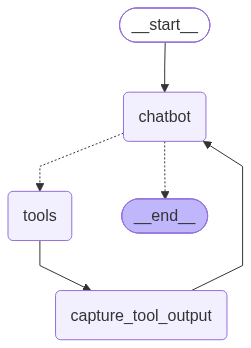

In [7]:
import json

from langchain_core.messages import SystemMessage, ToolMessage
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

SYSTEM_PROMPT = """
장소 요청은 먼저 extract_keywords로 검색어를 만들고, 그 결과를 사용해 kakao_search_place를 호출한다.
장소 검색 결과를 받으면 이름, 주소와 URL을 포함해 사용자에게 답한다.
"""

# 1. Tool·model·prompt 준비: 모델이 다음 행동을 정할 수 있도록 두 Tool schema를 연결한다.
tools = [extract_keywords, kakao_search_place]

llm = ChatOpenAI(
    model=OPENAI_CHAT_MODEL,
    use_responses_api=True,
)
# bind_tools(tools): Tool schema를 모델에 알려 tool_calls를 만들 수 있게 하며 Tool을 실행하지는 않는다.
llm_with_tools = llm.bind_tools(tools)

# 2. chatbot Node: State의 messages를 읽어 다음 AIMessage를 만든다.
def chatbot(state: State) -> dict:
    # 입력 → 변환: 고정 정책과 누적 message를 모델에 전달해 Tool 요청 또는 최종 답변을 받는다.
    response = llm_with_tools.invoke(
        [SystemMessage(content=SYSTEM_PROMPT), *state["messages"]]
    )
    # 출력 → 다음 사용처: add_messages가 response를 messages에 합치고 tools_condition이 이를 검사한다.
    return {"messages": [response]}

# 3. capture_tool_output Node: ToolMessage를 업무용 State key로 옮긴다.
def capture_tool_output(state: State) -> dict:
    """마지막 ToolMessage를 업무용 Custom State key로 복사한다."""
    # 입력: ToolNode가 messages 끝에 추가한 실행 결과 message이다.
    last_message = state["messages"][-1]
    # ToolMessage가 아니면 갱신할 Tool 결과가 없으므로 빈 부분 update를 반환한다.
    if not isinstance(last_message, ToolMessage):
        return {}
    # 변환·출력: 검색어 문자열은 search_query의 새 값으로 교체한다.
    if last_message.name == "extract_keywords":
        return {"search_query": str(last_message.content)}
    # 변환·출력: 장소 JSON 문자열은 list[KakaoPlace]로 바꿔 search_results에 저장한다.
    if last_message.name == "kakao_search_place":
        # json.loads(str): ToolMessage.content의 JSON str를 Python list로 역직렬화한다.
        return {"search_results": json.loads(str(last_message.content))}
    # 등록되지 않은 Tool 이름은 업무 key에 저장하지 않는다.
    return {}

# 4. wiring·compile: 세 Node와 Edge를 builder에 등록한다. 등록 시점에는 실행하지 않는다.
workflow = StateGraph(State)

workflow.add_node("chatbot", chatbot)
workflow.add_node("tools", ToolNode(tools))
workflow.add_node("capture_tool_output", capture_tool_output)

workflow.add_edge(START, "chatbot")

workflow.add_conditional_edges(
    "chatbot",
    tools_condition,
)

workflow.add_edge("tools", "capture_tool_output")
workflow.add_edge("capture_tool_output", "chatbot")

graph = workflow.compile()
graph


## 5단계: 그래프를 실행하고 Custom State 확인하기

`graph.invoke(initial_state)`는 입력 State에서 시작해 Tool 반복이 끝날 때까지 실행한 뒤 **최종 State `dict`**를 반환한다. 입력의 `None`은 아직 Tool 결과가 없다는 뜻이며, 실행이 끝나면 capture Node가 실제 값으로 교체해야 한다. `StateSnapshot`은 Checkpointer가 연결된 그래프에서 `get_state()`로 조회하는 별도 객체이므로 여기의 반환값과 구분한다.

먼저 자연어 답변보다 `search_query`와 `search_results`를 확인한다. 검색어가 채워지고 결과 수가 0보다 크면 두 Tool 결과가 Custom State까지 전달된 것이다. 장소 검색 결과는 시점·API 응답에 따라 달라질 수 있다.


In [8]:
initial_state = {
    "messages": [("human", "남부터미널에서 돈가스 맛집을 찾아 줘.")],
    "search_query": None,
    "search_results": None,
}
# graph.invoke(input): START부터 END까지 Node를 실행하고 모든 key가 누적된 최종 State dict를 반환한다.
final_state = graph.invoke(
    initial_state,  # input: HumanMessage 하나와 비어 있는 업무용 key를 가진 시작 State이다.
)

# 출력 → 다음 사용처: capture_tool_output이 채운 검색어와 장소 수를 먼저 검증한다.
print("search_query:", final_state["search_query"])
# search_results가 None이면 빈 list로 바꾼 뒤 길이를 계산해 TypeError를 피한다.
print("result count:", len(final_state["search_results"] or []))

search_query: 남부터미널 돈가스 맛집
result count: 5


## 6단계: 최종 AI 답변 표시하기

마지막 `chatbot`은 장소 결과가 담긴 `ToolMessage`를 읽고 사용자용 `AIMessage`를 만든다. `final_state["messages"][-1]`은 이 최종 message이다.

Responses API에서는 `content`가 block 목록일 수 있으므로 Markdown에는 텍스트를 정규화한 `.text`를 전달한다. 이 자연어 답변은 사용자 화면용이고, 프로그램이 재사용할 원본 장소 목록은 `search_results`에 그대로 남아 있다.


In [9]:
from IPython.display import Markdown
Markdown(final_state["messages"][-1].text)

남부터미널 인근 돈가스 맛집을 찾아봤어요.

- **허수아비돈까스** — 서울 서초구 서초동 1451-52  
  [카카오맵 보기](http://place.map.kakao.com/10916911)
- **카츠공방 서초본점** — 서울 서초구 서초동 1458-1  
  [카카오맵 보기](http://place.map.kakao.com/1051236291)
- **가츠오** — 서울 서초구 서초동 1658-17  
  [카카오맵 보기](http://place.map.kakao.com/1943855220)
- **미토요** — 서울 서초구 서초동 1602-1  
  [카카오맵 보기](http://place.map.kakao.com/1130437770)
- **허수아비 남부터미널점** — 서울 서초구 서초동 1603-69  
  [카카오맵 보기](http://place.map.kakao.com/8612345)

## 7단계: Tool 호출 ID로 요청과 결과 연결하기

한 번의 실행에는 Tool 호출이 두 번 생길 수 있다. 각 요청과 결과는 이름뿐 아니라 **호출 ID**로 연결된다.

| 위치 | 확인할 값 | 의미 |
|---|---|---|
| Tool을 요청한 `AIMessage` | `tool_calls[i]["id"]` | 모델이 만든 Tool 요청의 고유 ID이다. |
| Tool 결과인 `ToolMessage` | `tool_call_id` | 어느 요청에 대한 결과인지 가리키는 같은 ID이다. |
| `ToolMessage.name` | `extract_keywords` 또는 `kakao_search_place` | `capture_tool_output`이 저장할 State key를 고르는 기준이다. |

예상 순서는 `human → ai(키워드 요청) → tool(키워드 결과) → ai(장소 요청) → tool(장소 결과) → ai(최종 답변)`이다. 두 ID 쌍은 서로 다르며 실행할 때마다 값이 바뀔 수 있다.

`ToolNode`가 ID 연결을 자동으로 유지하므로 LLM은 여러 Tool 결과 중 어느 요청의 응답인지 구분한다. `capture_tool_output`은 ID가 아니라 마지막 `ToolMessage.name`을 보고 `search_query` 또는 `search_results`를 갱신한다.


In [10]:
from pprint import pprint
for message in final_state["messages"]:

    pprint(
        {
            "type": message.type,
            "name": getattr(message, "name", None),
            "tool_calls": getattr(message, "tool_calls", []),
            "tool_call_id": getattr(message, "tool_call_id", None),
        }
    )

{'name': None, 'tool_call_id': None, 'tool_calls': [], 'type': 'human'}
{'name': None,
 'tool_call_id': None,
 'tool_calls': [{'args': {'user_request': '남부터미널에서 돈가스 맛집을 찾아 줘.'},
                 'id': 'call_C79JIGr54l5k3ZCpMREjptUY',
                 'name': 'extract_keywords',
                 'type': 'tool_call'}],
 'type': 'ai'}
{'name': 'extract_keywords',
 'tool_call_id': 'call_C79JIGr54l5k3ZCpMREjptUY',
 'tool_calls': [],
 'type': 'tool'}
{'name': None,
 'tool_call_id': None,
 'tool_calls': [{'args': {'query': '남부터미널 돈가스 맛집'},
                 'id': 'call_mM7dfUlS3RhwLTBRjZeG3rWn',
                 'name': 'kakao_search_place',
                 'type': 'tool_call'}],
 'type': 'ai'}
{'name': 'kakao_search_place',
 'tool_call_id': 'call_mM7dfUlS3RhwLTBRjZeG3rWn',
 'tool_calls': [],
 'type': 'tool'}
{'name': None, 'tool_call_id': None, 'tool_calls': [], 'type': 'ai'}


## 8단계: 짧은 요청으로 같은 그래프 재사용하기

이번에는 이미 검색어에 가까운 `남부터미널 맛집`을 같은 compiled graph에 전달한다. 별도 분기 코드는 없으며 모델이 Tool 사용 여부와 순서를 판단한다.

이 그래프에는 checkpointer가 없으므로 두 번째 `invoke()`는 첫 실행의 대화를 이어 가지 않는 **독립 실행**이다. 다만 State schema와 Node·Edge 구조는 그대로 재사용한다.


In [11]:
second_state = graph.invoke(
    {
        "messages": [("human", "남부터미널 맛집")],  # messages: 새 실행의 사용자 요청이다.
        "search_query": None,                          # search_query: Tool 실행 전 초기값이다.
        "search_results": None,                        # search_results: Tool 실행 전 초기값이다.
    }
)

Markdown(second_state["messages"][-1].text)

남부터미널 주변 맛집을 소개해 드릴게요.

1. **봉산옥 서초동본점**  
   주소: 서울 서초구 서초동 1451-9  
   [카카오맵에서 보기](http://place.map.kakao.com/7908112)

2. **루엘드파리 서초본점**  
   주소: 서울 서초구 서초동 1445-13  
   [카카오맵에서 보기](http://place.map.kakao.com/26455895)

3. **부라문 서초점**  
   주소: 서울 서초구 서초동 1450-2  
   [카카오맵에서 보기](http://place.map.kakao.com/26436716)

4. **예술상회**  
   주소: 서울 서초구 서초동 1457-4  
   [카카오맵에서 보기](http://place.map.kakao.com/870803372)

5. **시골집**  
   주소: 서울 서초구 서초동 1459-11  
   [카카오맵에서 보기](http://place.map.kakao.com/16046732)

## 9단계: 후속 코드가 사용할 구조화된 값 확인하기

마지막으로 `second_state`에서 업무용 key만 선택한다.

- `search_query`: 실제 장소 검색에 사용된 문자열이다.
- `search_results`: 이름·주소·URL을 가진 장소 딕셔너리 목록이다.

이 값들은 자연어 답변을 다시 파싱하지 않고 지도 marker 생성, 검색 로그 저장, 별도 API 응답 구성에 바로 사용할 수 있다.


In [12]:
{
    "search_query": second_state["search_query"],
    "search_results": second_state["search_results"],
}


{'search_query': '남부터미널 맛집',
 'search_results': [{'name': '봉산옥 서초동본점',
   'address': '서울 서초구 서초동 1451-9',
   'url': 'http://place.map.kakao.com/7908112'},
  {'name': '루엘드파리 서초본점',
   'address': '서울 서초구 서초동 1445-13',
   'url': 'http://place.map.kakao.com/26455895'},
  {'name': '부라문 서초점',
   'address': '서울 서초구 서초동 1450-2',
   'url': 'http://place.map.kakao.com/26436716'},
  {'name': '예술상회',
   'address': '서울 서초구 서초동 1457-4',
   'url': 'http://place.map.kakao.com/870803372'},
  {'name': '시골집',
   'address': '서울 서초구 서초동 1459-11',
   'url': 'http://place.map.kakao.com/16046732'}]}